# Final Project for Foundation of Data Science Lab

Anjali Baral [ACE081BCT014], 
Garima Niroula [ACE081BCT030]

## Problem Definition

The objective of this project is to predict whether a student will pass or fail based on their study hours, attendance, and previous exam score.

Since the target variable Pass has two categories (0 = Fail, 1 = Pass), this is a classification problem, so Logistic Regression is used.

## Dataset Name

Dataset Name: Student Performance Dataset

This dataset contains information about students such as study hours,
attendance, and previous scores. It is used to predict whether a
student will pass or fail.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [29]:
df = pd.read_csv("student_performance_dataset.csv")

df.head()

,StudyHours,Attendance,PreviousScore,Pass
0,7,65,86,1
1,4,94,83,1
2,5,67,83,1
3,7,96,92,1
4,3,73,86,1


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   StudyHours     120 non-null    int64
 1   Attendance     120 non-null    int64
 2   PreviousScore  120 non-null    int64
 3   Pass           120 non-null    int64
dtypes: int64(4)
memory usage: 3.9 KB


## Exploratory Data Analysis (EDA) 

Dataset description

In [31]:
df.describe()

,StudyHours,Attendance,PreviousScore,Pass
count,120.000000,120.000000,120.000000,120.000000
mean,4.683333,74.816667,65.283333,0.700000
std,2.173110,13.934410,19.000302,0.460179
min,1.000000,50.000000,35.000000,0.000000
25%,3.000000,62.750000,50.000000,0.000000
50%,5.000000,76.000000,66.000000,1.000000
75%,7.000000,86.500000,83.000000,1.000000
max,8.000000,98.000000,94.000000,1.000000


Check missing values

In [32]:
df.isnull().sum()

StudyHours       0
Attendance       0
PreviousScore    0
Pass             0
dtype: int64

Correlation Heatmap

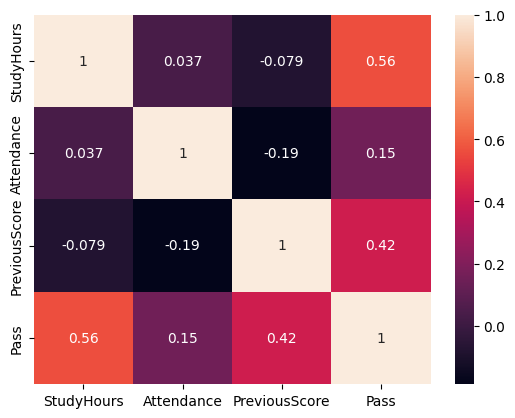

In [36]:
sns.heatmap(df.corr(), annot=True)
plt.show()

## Data Preprocessing

Define features and target

In [37]:
X = df[['StudyHours','Attendance','PreviousScore']]
y = df['Pass']

Train-Test Split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Building (Logistic Regression)

In [33]:
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Prediction

In [34]:
y_pred = model.predict(X_test)

## Model Evaluation

In [24]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 1.0


In [25]:
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1 0]
 [0 2]]


In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



## Visualization

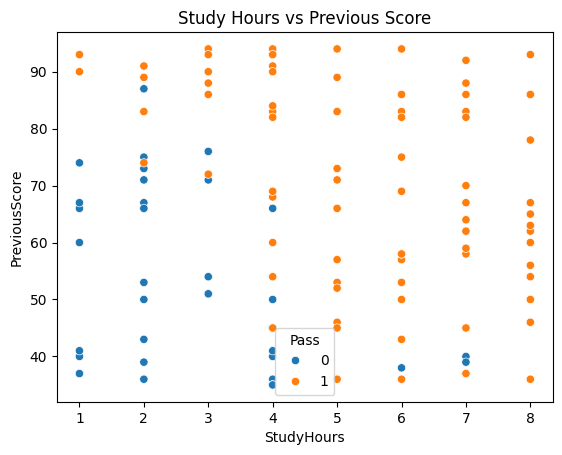

In [35]:
sns.scatterplot(x=df['StudyHours'], y=df['PreviousScore'], hue=df['Pass'])
plt.title("Study Hours vs Previous Score")
plt.show()

## Interpretation & Conclusion

The Logistic Regression model was trained using study hours, attendance, and previous scores to predict whether a student will pass or fail.

The model achieved a good accuracy score, showing that these factors strongly influence student performance.

Students with higher study hours and better attendance are more likely to pass.

This project demonstrates how machine learning can help analyze and predict student performance.